In [101]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

**Exercise 1. Données simulées**
Part(1(a)),(b)).

In [102]:
np.random.seed(42)

In [103]:

normal_sample = np.random.normal(loc=-1.5, scale=np.sqrt(2), size=50)

uniform_sample = np.random.uniform(low=0, high=1, size=50)


<Figure size 1500x600 with 0 Axes>

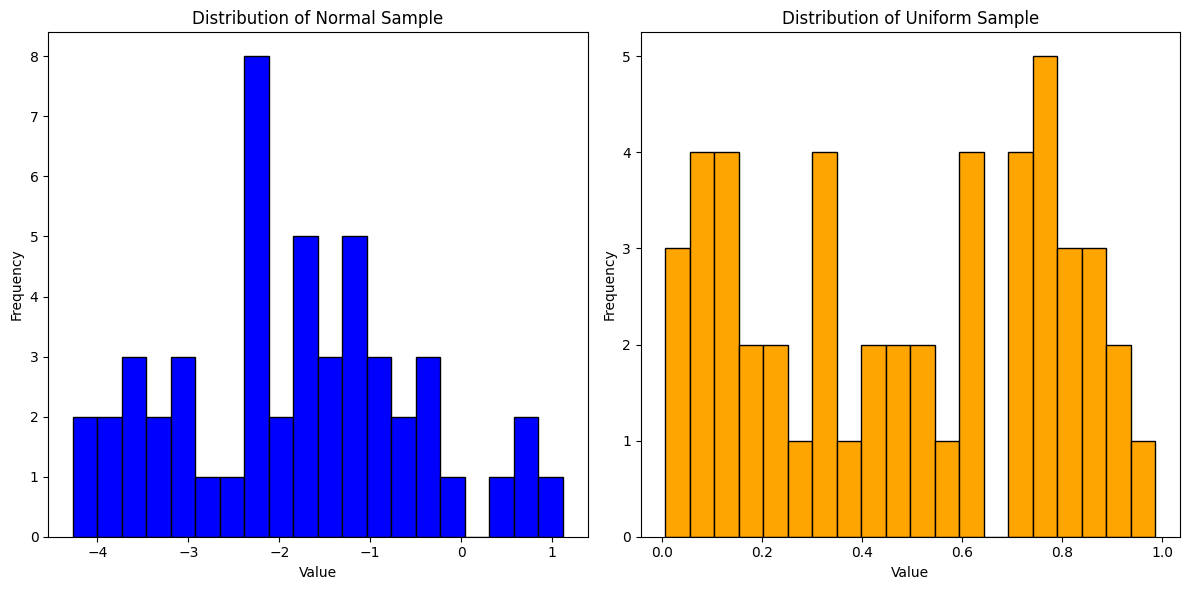

In [104]:
#just for intuition and expirements!
plt.figure(figsize=(15, 6))

# we are creating two subplots!
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

axs[0].hist(normal_sample, bins=20, color='blue', edgecolor='black')
axs[0].set_title("Distribution of Normal Sample")
axs[0].set_xlabel("Value")
axs[0].set_ylabel("Frequency")

axs[1].hist(uniform_sample, bins=20, color='orange', edgecolor='black')
axs[1].set_title("Distribution of Uniform Sample")
axs[1].set_xlabel("Value")
axs[1].set_ylabel("Frequency")


plt.tight_layout()
#plt.savefig("histogram of normal and uniform sample")
plt.show()

**Exercise 1. Données simulées**
Part(1(c)).

In [105]:
X = np.concatenate((normal_sample, uniform_sample))
print(X)



[-0.79754011 -1.69553525 -0.58403009  0.65388948 -1.83114288 -1.83111966
  0.73334418 -0.4146834  -2.16393704 -0.73270423 -2.15537159 -2.15864133
 -1.15781367 -4.20578687 -3.93940219 -2.29519465 -2.93235951 -1.05558716
 -2.78413996 -3.49729905  0.57274037 -1.81929591 -1.4045007  -3.51489821
 -2.26987343 -1.34313177 -3.12775073 -0.96868277 -2.34943138 -1.91251726
 -2.35094165  1.11951693 -1.51908796 -2.99582914 -0.33674583 -3.22653365
 -1.20462227 -4.27139207 -3.37833872 -1.22159617 -0.45565055 -1.25764865
 -1.66355137 -1.92582493 -3.59094585 -2.51801344 -2.1514416  -0.00500341
 -1.01405035 -3.9933153   0.14092422  0.80219698  0.07455064  0.98688694
  0.77224477  0.19871568  0.00552212  0.81546143  0.70685734  0.72900717
  0.77127035  0.07404465  0.35846573  0.11586906  0.86310343  0.62329813
  0.33089802  0.06355835  0.31098232  0.32518332  0.72960618  0.63755747
  0.88721274  0.47221493  0.11959425  0.71324479  0.76078505  0.5612772
  0.77096718  0.4937956   0.52273283  0.42754102  0.

**Exercise 1. Données simulées**
Part(2(a)).

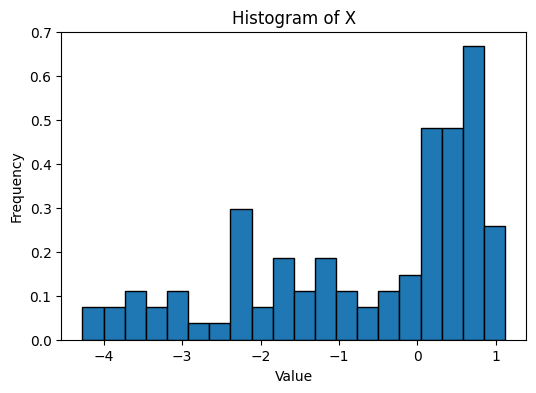

In [106]:
X = np.concatenate((normal_sample, uniform_sample))
plt.figure(figsize=(6,4))
plt.hist(X, bins=20, edgecolor='black' , density = True)
plt.title("Histogram of X")
plt.xlabel("Value")
plt.ylabel("Frequency")
#plt.savefig("distribution of data X")
plt.show()

**Exercise 1. Données simulées**
Part(2(b)).

In [107]:

#we have chosen two kernel functions for expirementation!

def gaussian_kernel(u):
    return (1 / np.sqrt(2 * np.pi)) * np.exp(-u**2 / 2)

def triangular_kernel(u):
    return (1 - np.abs(u)) * (np.abs(u) <= 1)



In [108]:
def density_estimator(h, x, X, K):
    n = len(X)
    x = np.atleast_1d(x)  
    estimator = np.array([np.sum(K((X - xi) / h)) / (n * h) for xi in x])
    return estimator if len(estimator) > 1 else estimator[0]  
   

In [109]:
x = np.linspace(-5,1.5, 500)

In [110]:
small_h = 0.01


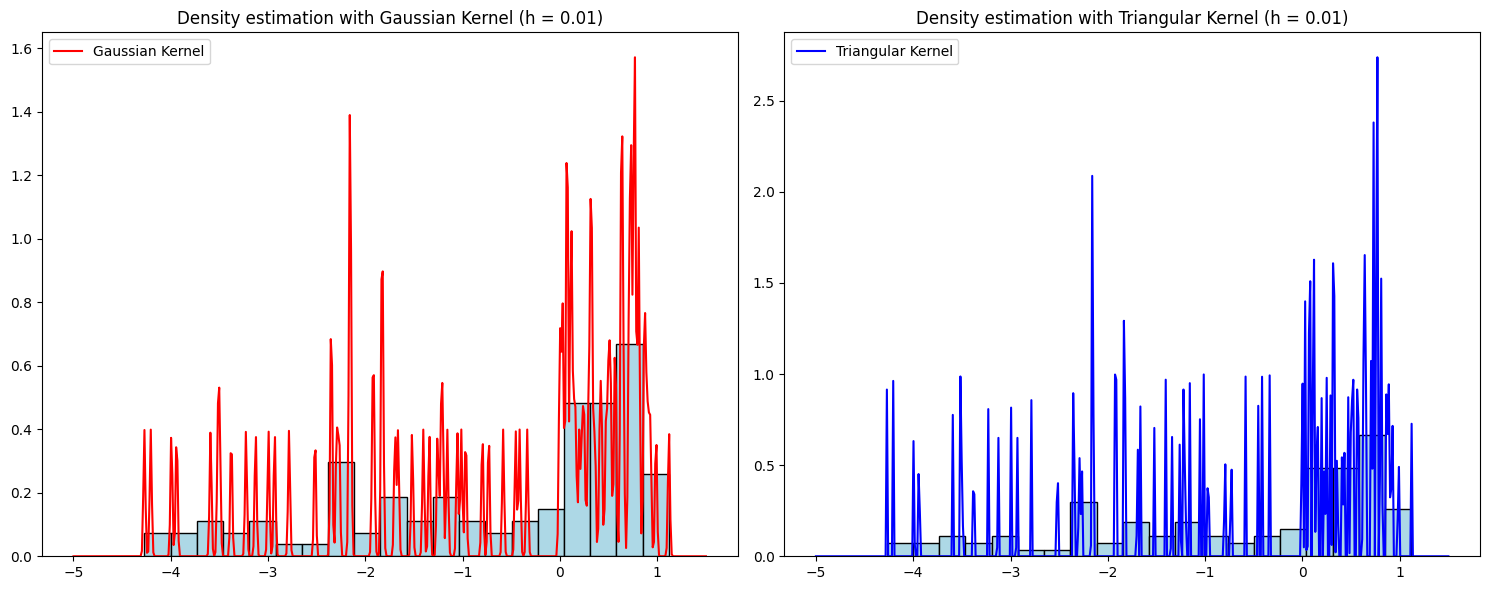

In [111]:
fig, axs = plt.subplots(1, 2, figsize=(15, 6))

axs[0].hist(X, bins=20, color='lightblue', edgecolor='black', density=True)
axs[0].plot(x, density_estimator(small_h, x, X, gaussian_kernel), color='red', label="Gaussian Kernel")
axs[0].legend()
axs[0].set_title("Density estimation with Gaussian Kernel (h = 0.01)")



axs[1].hist(X, bins=20, color='lightblue', edgecolor='black', density=True)
axs[1].plot(x, density_estimator(small_h, x, X, triangular_kernel), color='blue', label="Triangular Kernel")
axs[1].legend()
axs[1].set_title("Density estimation with Triangular Kernel (h = 0.01)")



plt.tight_layout()
#plt.savefig("Estimation with very small h")
plt.show()

In [112]:
large_h = [3, 5]


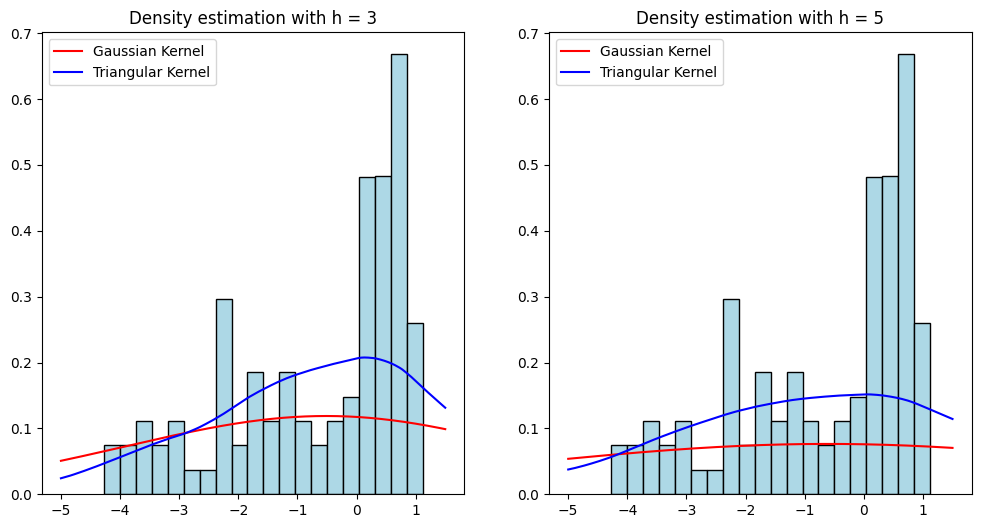

In [113]:
plt.figure(figsize=(12, 6))
for i, h in enumerate(large_h):
    plt.subplot(1, 2, i+1)
    plt.hist(X, bins=20, color='lightblue', edgecolor='black', density=True)
    plt.plot(x, density_estimator(h, x, X, gaussian_kernel), color='red', label="Gaussian Kernel")
    plt.plot(x, density_estimator(h, x, X, triangular_kernel), color='blue', label="Triangular Kernel")

    plt.legend()
    plt.title(f"Density estimation with h = {h}")
    #plt.savefig("Estimation with large h")
plt.show()

In [114]:
small_h_values = [0.3, 0.6]

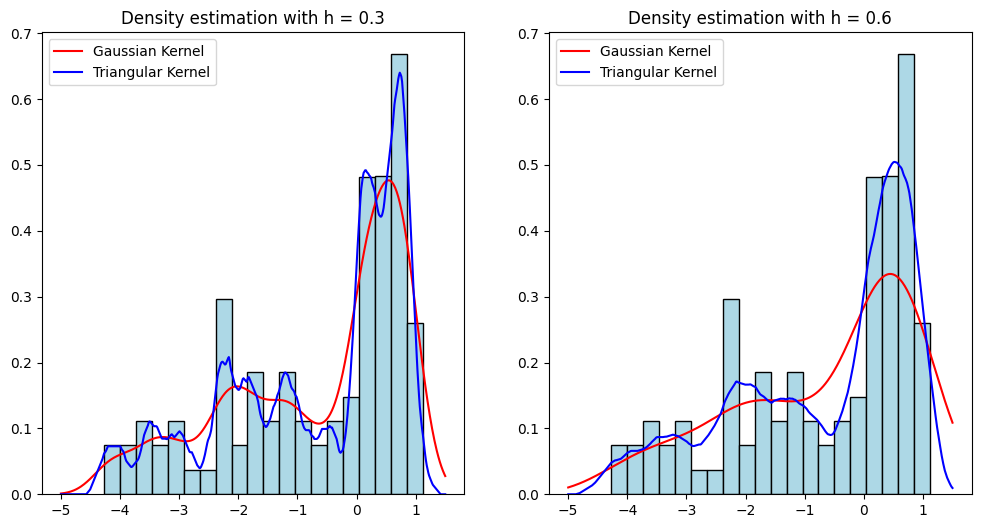

In [115]:


plt.figure(figsize=(12, 6))
for i, h in enumerate(small_h_values):
    plt.subplot(1, 2, i+1)
    plt.hist(X, bins=20, color='lightblue', edgecolor='black', density=True)
    plt.plot(x, density_estimator(h, x, X, gaussian_kernel), color='red', label="Gaussian Kernel")
    plt.plot(x, density_estimator(h, x, X, triangular_kernel), color='blue', label="Triangular Kernel")
    
    
    plt.legend()
    plt.title(f"Density estimation with h = {h}")
    #plt.savefig("Estimation with relatively smaller values of h")
plt.show()

**Exercise 1. Données simulées**
Part(2(c)).

In [116]:
def simple_integrate(h, K, X, x_range=(-10, 10), step_size=0.1):
    x_vals = np.arange(x_range[0], x_range[1], step_size)
    density_vals = density_estimator(h, x_vals, X, K)**2
    integral = 0
    for i in range(1, len(x_vals)):
        integral += 0.5 * (density_vals[i] + density_vals[i - 1]) * step_size
    return integral

In [117]:
def cv(h, K, simple_integrate, X):
    n = len(X)
    int_value = simple_integrate(h, K, X)
    cons_of_int = 2 / (n * h * (n - 1))
    matr = np.outer(X, X) - X[:, None]

    result_matrix = K(matr / h)
    np.fill_diagonal(result_matrix, 0)

    result = np.sum(result_matrix)

    return int_value - (cons_of_int * result)

In [118]:


h_values = np.linspace(0.1, 2, 50)


cv_scores = [cv(h,gaussian_kernel, simple_integrate, X) for h in h_values]


best_h = h_values[np.argmin(cv_scores)]

print(f"Best h value: {best_h}")

Best h value: 0.1


In [119]:
h =0.1

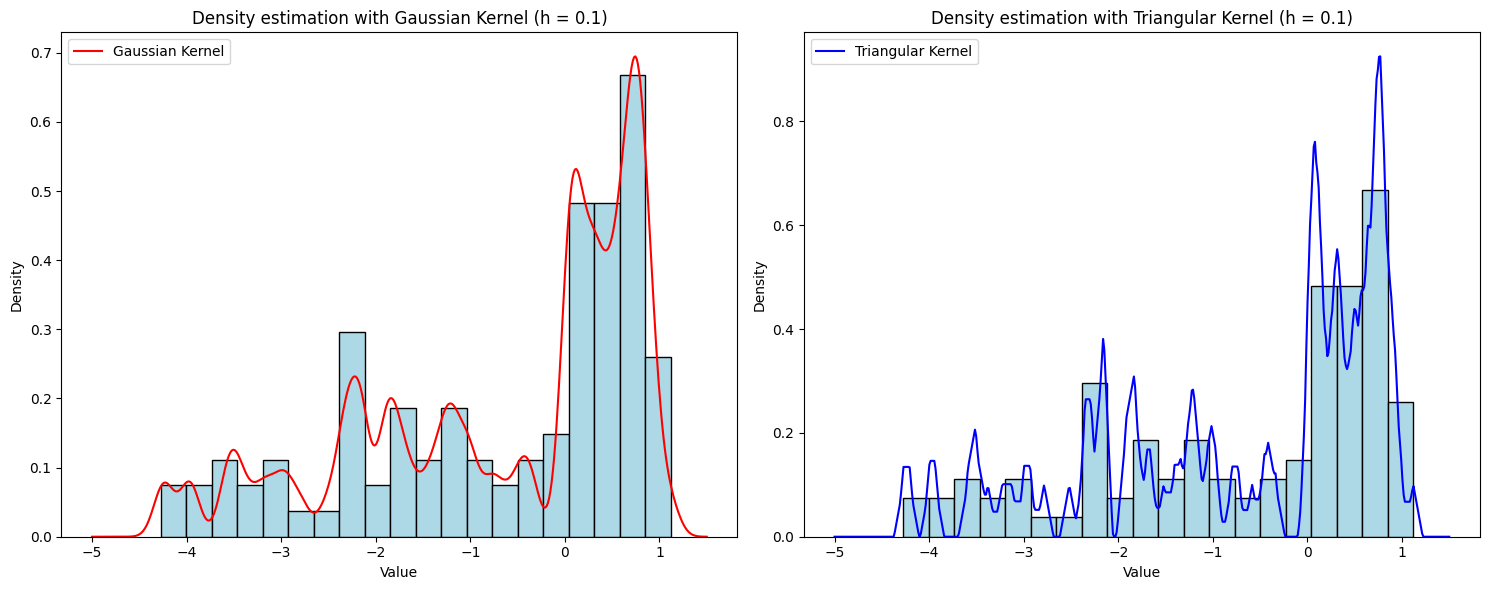

In [120]:
fig, axs = plt.subplots(1, 2, figsize=(15, 6))

axs[0].hist(X, bins=20, color='lightblue', edgecolor='black', density=True)
axs[0].plot(x, density_estimator(h, x, X, gaussian_kernel), color='red', label="Gaussian Kernel")
axs[0].legend()
axs[0].set_title("Density estimation with Gaussian Kernel (h = 0.1)")
axs[0].set_xlabel("Value")
axs[0].set_ylabel("Density")


axs[1].hist(X, bins=20, color='lightblue', edgecolor='black', density=True)
axs[1].plot(x, density_estimator(h, x, X, triangular_kernel), color='blue', label="Triangular Kernel")
axs[1].legend()
axs[1].set_title("Density estimation with Triangular Kernel (h = 0.1)")
axs[1].set_xlabel("Value")
axs[1].set_ylabel("Density")


plt.tight_layout()
#plt.savefig("Estimation with optimised h.png")
plt.show()

**Exercise#2**


**Expirements with the datasets**

In [121]:
df1 = pd.read_csv('ai4i2020.csv' , header=0)


df1.head()


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [122]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [123]:
df1.shape
df1.columns

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='object')

array([[<Axes: title={'center': 'UDI'}>,
        <Axes: title={'center': 'Air temperature [K]'}>,
        <Axes: title={'center': 'Process temperature [K]'}>],
       [<Axes: title={'center': 'Rotational speed [rpm]'}>,
        <Axes: title={'center': 'Torque [Nm]'}>,
        <Axes: title={'center': 'Tool wear [min]'}>],
       [<Axes: title={'center': 'Machine failure'}>,
        <Axes: title={'center': 'TWF'}>, <Axes: title={'center': 'HDF'}>],
       [<Axes: title={'center': 'PWF'}>, <Axes: title={'center': 'OSF'}>,
        <Axes: title={'center': 'RNF'}>]], dtype=object)

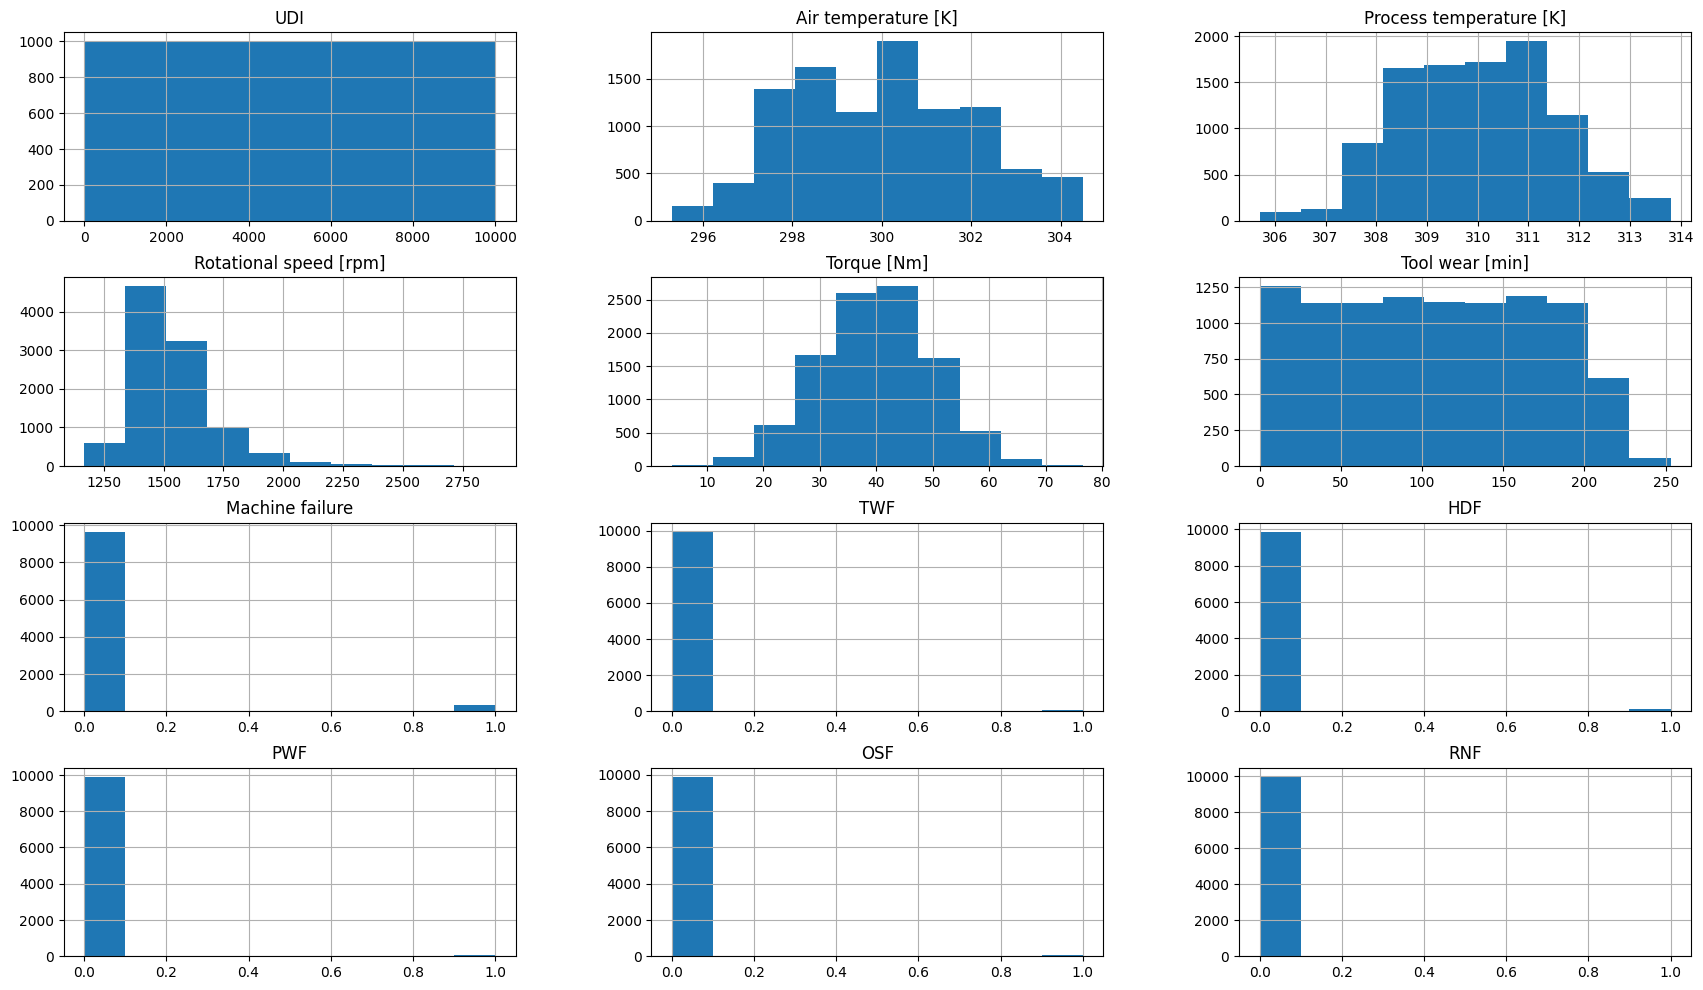

In [124]:
df1.hist(figsize=(21,12))

In [125]:

data_column_torque = df1['Torque [Nm]'].dropna()  
X_df_column_torque = data_column_torque.to_numpy()


In [126]:
h_values = np.linspace(0.1, 2, 10) 

In [127]:

cv_scores = [cv(h, gaussian_kernel, simple_integrate, X_df_column_torque) for h in h_values]


best_h = h_values[np.argmin(cv_scores)]
print(f"Best h value: {best_h}")

Best h value: 1.1555555555555557


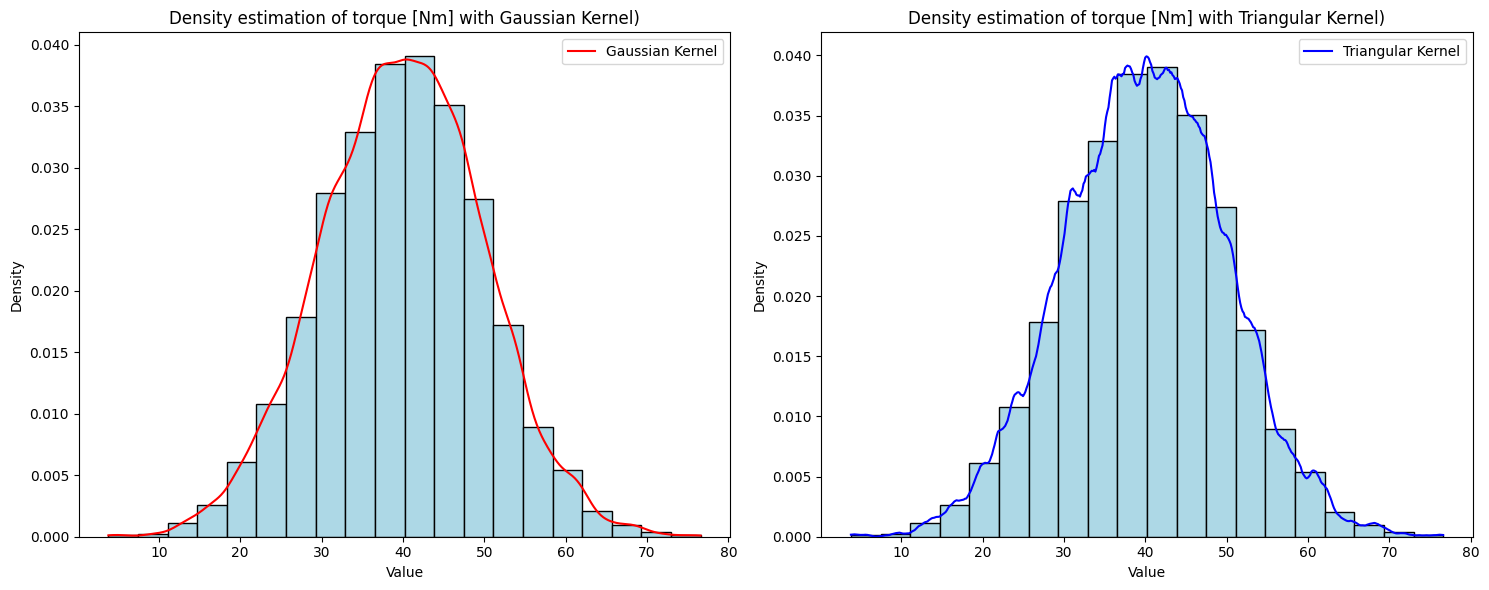

In [128]:
x_df_column_torque= np.linspace(min(X_df_column_torque) , max(X_df_column_torque) , 500) 
fig, axs = plt.subplots(1, 2, figsize=(15, 6))


axs[0].hist(X_df_column_torque, bins=20, color='lightblue', edgecolor='black', density=True)
axs[0].plot(x_df_column_torque, density_estimator(best_h,x_df_column_torque, X_df_column_torque, gaussian_kernel), color='red', label="Gaussian Kernel")
axs[0].legend()
axs[0].set_title(f"Density estimation of torque [Nm] with Gaussian Kernel)")
axs[0].set_xlabel("Value")
axs[0].set_ylabel("Density")


axs[1].hist(X_df_column_torque, bins=20, color='lightblue', edgecolor='black', density=True)
axs[1].plot(x_df_column_torque, density_estimator(best_h, x_df_column_torque, X_df_column_torque, triangular_kernel), color='blue', label="Triangular Kernel")
axs[1].legend()
axs[1].set_title(f"Density estimation of torque [Nm] with Triangular Kernel)")
axs[1].set_xlabel("Value")
axs[1].set_ylabel("Density")



plt.tight_layout()
#plt.savefig("estimation of torque [Nm]")
plt.show()

In [129]:

data_column_Air_temperature = df1['Air temperature [K]'].dropna()  

X_df_column_Air_temperature = data_column_Air_temperature.to_numpy()

In [130]:
cv_scores = [cv(h, gaussian_kernel, simple_integrate, X_df_column_Air_temperature) for h in h_values]


best_h_Air_temperature = h_values[np.argmin(cv_scores)]
print(f"Best h for air temperature value: {best_h_Air_temperature}")

Best h for air temperature value: 0.1


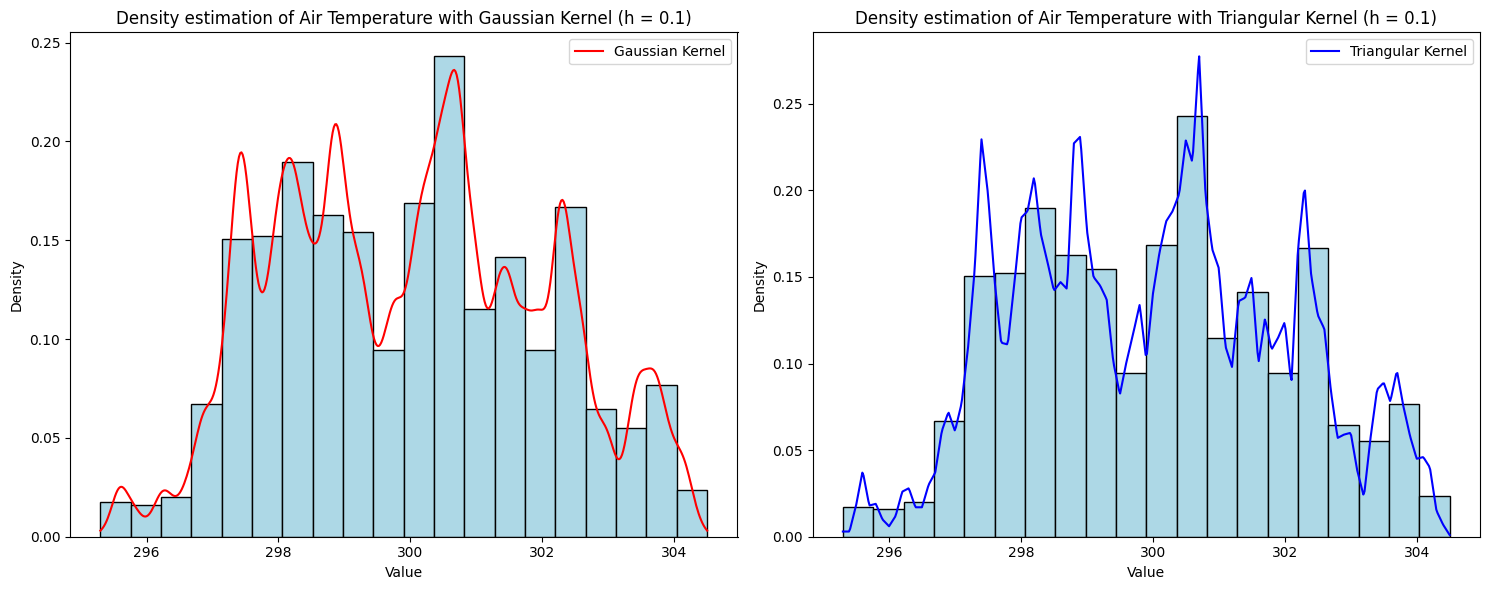

In [131]:
x_df_column_Air_temperature= np.linspace(min(X_df_column_Air_temperature) , max(X_df_column_Air_temperature) , 500)  # Range of x values for KDE plotting
fig, axs = plt.subplots(1, 2, figsize=(15, 6))

axs[0].hist(X_df_column_Air_temperature, bins=20, color='lightblue', edgecolor='black', density=True)
axs[0].plot(x_df_column_Air_temperature, density_estimator(best_h_Air_temperature,x_df_column_Air_temperature, X_df_column_Air_temperature, gaussian_kernel), color='red', label="Gaussian Kernel")
axs[0].legend()
axs[0].set_title(f"Density estimation of Air Temperature with Gaussian Kernel (h = {best_h_Air_temperature})")
axs[0].set_xlabel("Value")
axs[0].set_ylabel("Density")


axs[1].hist(X_df_column_Air_temperature, bins=20, color='lightblue', edgecolor='black', density=True)
axs[1].plot(x_df_column_Air_temperature, density_estimator(best_h_Air_temperature,x_df_column_Air_temperature,X_df_column_Air_temperature, triangular_kernel), color='blue', label="Triangular Kernel")
axs[1].legend()
axs[1].set_title(f"Density estimation of Air Temperature with Triangular Kernel (h = {best_h_Air_temperature})")
axs[1].set_xlabel("Value")
axs[1].set_ylabel("Density")

plt.tight_layout()
#plt.savefig("estimation of Air Temperature")
plt.show()

In [132]:

data_column_process_temperature = df1['Process temperature [K]'].dropna()  
X_df_column_process_temperature = data_column_process_temperature.to_numpy()

In [133]:

cv_scores = [cv(h, gaussian_kernel, simple_integrate, X_df_column_process_temperature) for h in h_values]

best_h_process_temperature = h_values[np.argmin(cv_scores)]
print(f"Best h for process temperature value: {best_h_process_temperature}")

Best h for process temperature value: 0.1


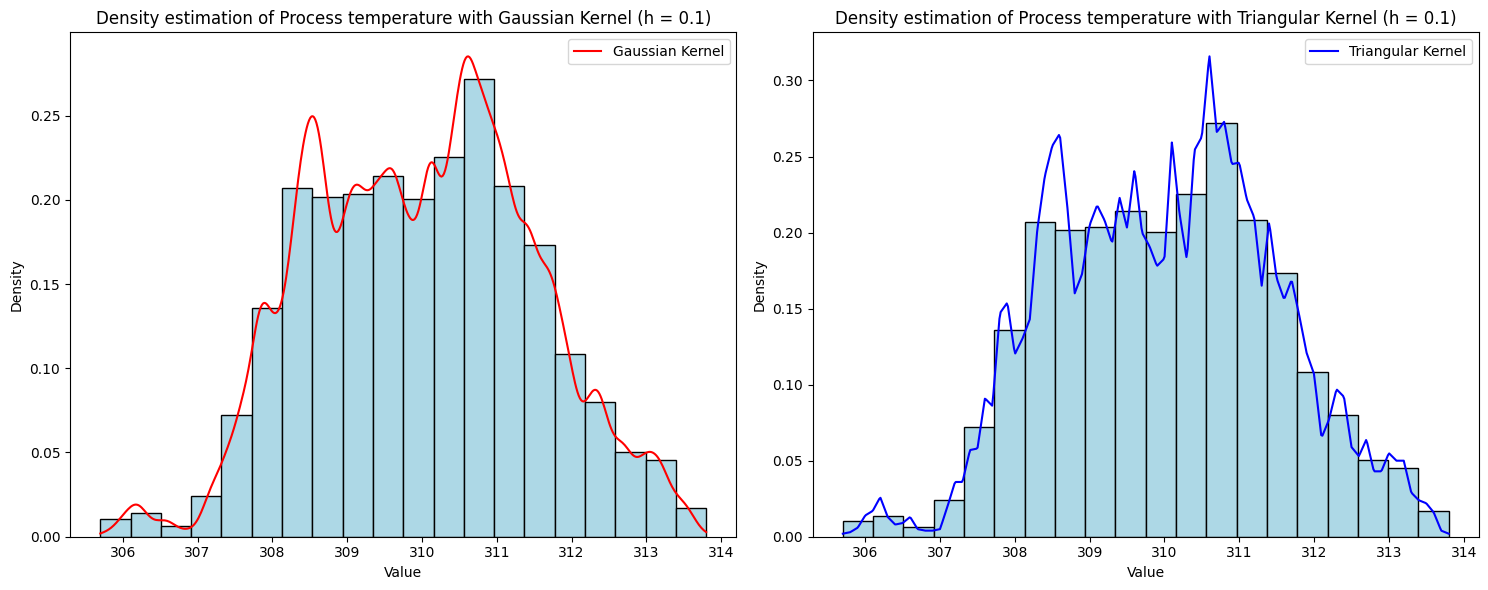

In [134]:
x_df_column_process_temperature= np.linspace(min(X_df_column_process_temperature) , max(X_df_column_process_temperature) , 500)  # Range of x values for KDE plotting
fig, axs = plt.subplots(1, 2, figsize=(15, 6))


axs[0].hist(X_df_column_process_temperature, bins=20, color='lightblue', edgecolor='black', density=True)
axs[0].plot(x_df_column_process_temperature, density_estimator(best_h_process_temperature,x_df_column_process_temperature, X_df_column_process_temperature, gaussian_kernel), color='red', label="Gaussian Kernel")
axs[0].legend()
axs[0].set_title(f"Density estimation of Process temperature with Gaussian Kernel (h = {best_h_process_temperature})")
axs[0].set_xlabel("Value")
axs[0].set_ylabel("Density")


axs[1].hist(X_df_column_process_temperature, bins=20, color='lightblue', edgecolor='black', density=True)
axs[1].plot(x_df_column_process_temperature, density_estimator(best_h_process_temperature,x_df_column_process_temperature,X_df_column_process_temperature, triangular_kernel), color='blue', label="Triangular Kernel")
axs[1].legend()
axs[1].set_title(f"Density estimation of Process temperature with Triangular Kernel (h = {best_h_process_temperature})")
axs[1].set_xlabel("Value")
axs[1].set_ylabel("Density")


plt.tight_layout()
#plt.savefig("estimation of process temperature")
plt.show()

In [135]:
data_column_rotational_speed = df1['Rotational speed [rpm]'].dropna() 
X_df_column_rotational_speed = data_column_rotational_speed.to_numpy()

In [136]:
h_values = np.linspace(0.1, 2, 10)
cv_scores = [cv(h, gaussian_kernel, simple_integrate, X_df_column_rotational_speed) for h in h_values]


best_h_rotational_speed = h_values[np.argmin(cv_scores)]
print(f"Best h value for rotational_speed: {best_h_rotational_speed}")

Best h value for rotational_speed: 0.1


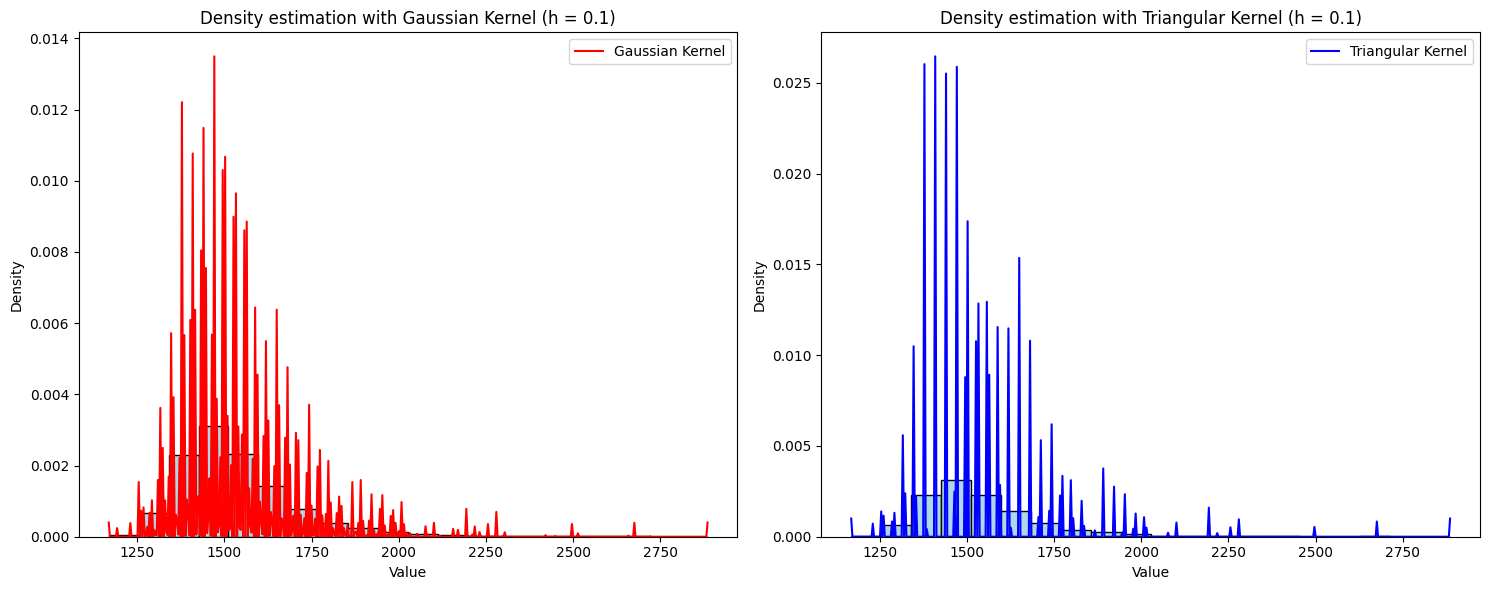

In [137]:
x_df_column_rotational_speed= np.linspace(min(X_df_column_rotational_speed) , max(X_df_column_rotational_speed) , 500)  # Range of x values for KDE plotting
fig, axs = plt.subplots(1, 2, figsize=(15, 6))


axs[0].hist(X_df_column_rotational_speed, bins=20, color='lightblue', edgecolor='black', density=True)
axs[0].plot(x_df_column_rotational_speed, density_estimator(best_h_rotational_speed,x_df_column_rotational_speed, X_df_column_rotational_speed, gaussian_kernel), color='red', label="Gaussian Kernel")
axs[0].legend()
axs[0].set_title(f"Density estimation with Gaussian Kernel (h = {best_h_rotational_speed})")
axs[0].set_xlabel("Value")
axs[0].set_ylabel("Density")


axs[1].hist(X_df_column_rotational_speed, bins=20, color='lightblue', edgecolor='black', density=True)
axs[1].plot(x_df_column_rotational_speed, density_estimator(best_h_rotational_speed,x_df_column_rotational_speed,X_df_column_rotational_speed, triangular_kernel), color='blue', label="Triangular Kernel")
axs[1].legend()
axs[1].set_title(f"Density estimation with Triangular Kernel (h = {best_h_rotational_speed})")
axs[1].set_xlabel("Value")
axs[1].set_ylabel("Density")


plt.tight_layout()
plt.show()

In [138]:
q1 = df1['Rotational speed [rpm]'].quantile(0.25)
q3 = df1['Rotational speed [rpm]'].quantile(0.75)
iqr = q3 - q1   #iqr is the Inter Quantile Range
q1 , q3 , iqr

(np.float64(1423.0), np.float64(1612.0), np.float64(189.0))

In [139]:
upper_limit = q3 + (1.5 * iqr)
lower_limit = q1 - (1.5 * iqr)
upper_limit, lower_limit

(np.float64(1895.5), np.float64(1139.5))

In [140]:
df1_copy = df1.copy()
df1_updated= df1[(df1['Rotational speed [rpm]'] <= upper_limit) & (df1['Rotational speed [rpm]'] >= lower_limit)]
print("before removing outliers:" , len(df1))
print("after removing outliers:" ,len(df1_updated))
print('outliers:', len(df1)-len(df1_updated))

before removing outliers: 10000
after removing outliers: 9582
outliers: 418


array([[<Axes: title={'center': 'UDI'}>,
        <Axes: title={'center': 'Air temperature [K]'}>,
        <Axes: title={'center': 'Process temperature [K]'}>],
       [<Axes: title={'center': 'Rotational speed [rpm]'}>,
        <Axes: title={'center': 'Torque [Nm]'}>,
        <Axes: title={'center': 'Tool wear [min]'}>],
       [<Axes: title={'center': 'Machine failure'}>,
        <Axes: title={'center': 'TWF'}>, <Axes: title={'center': 'HDF'}>],
       [<Axes: title={'center': 'PWF'}>, <Axes: title={'center': 'OSF'}>,
        <Axes: title={'center': 'RNF'}>]], dtype=object)

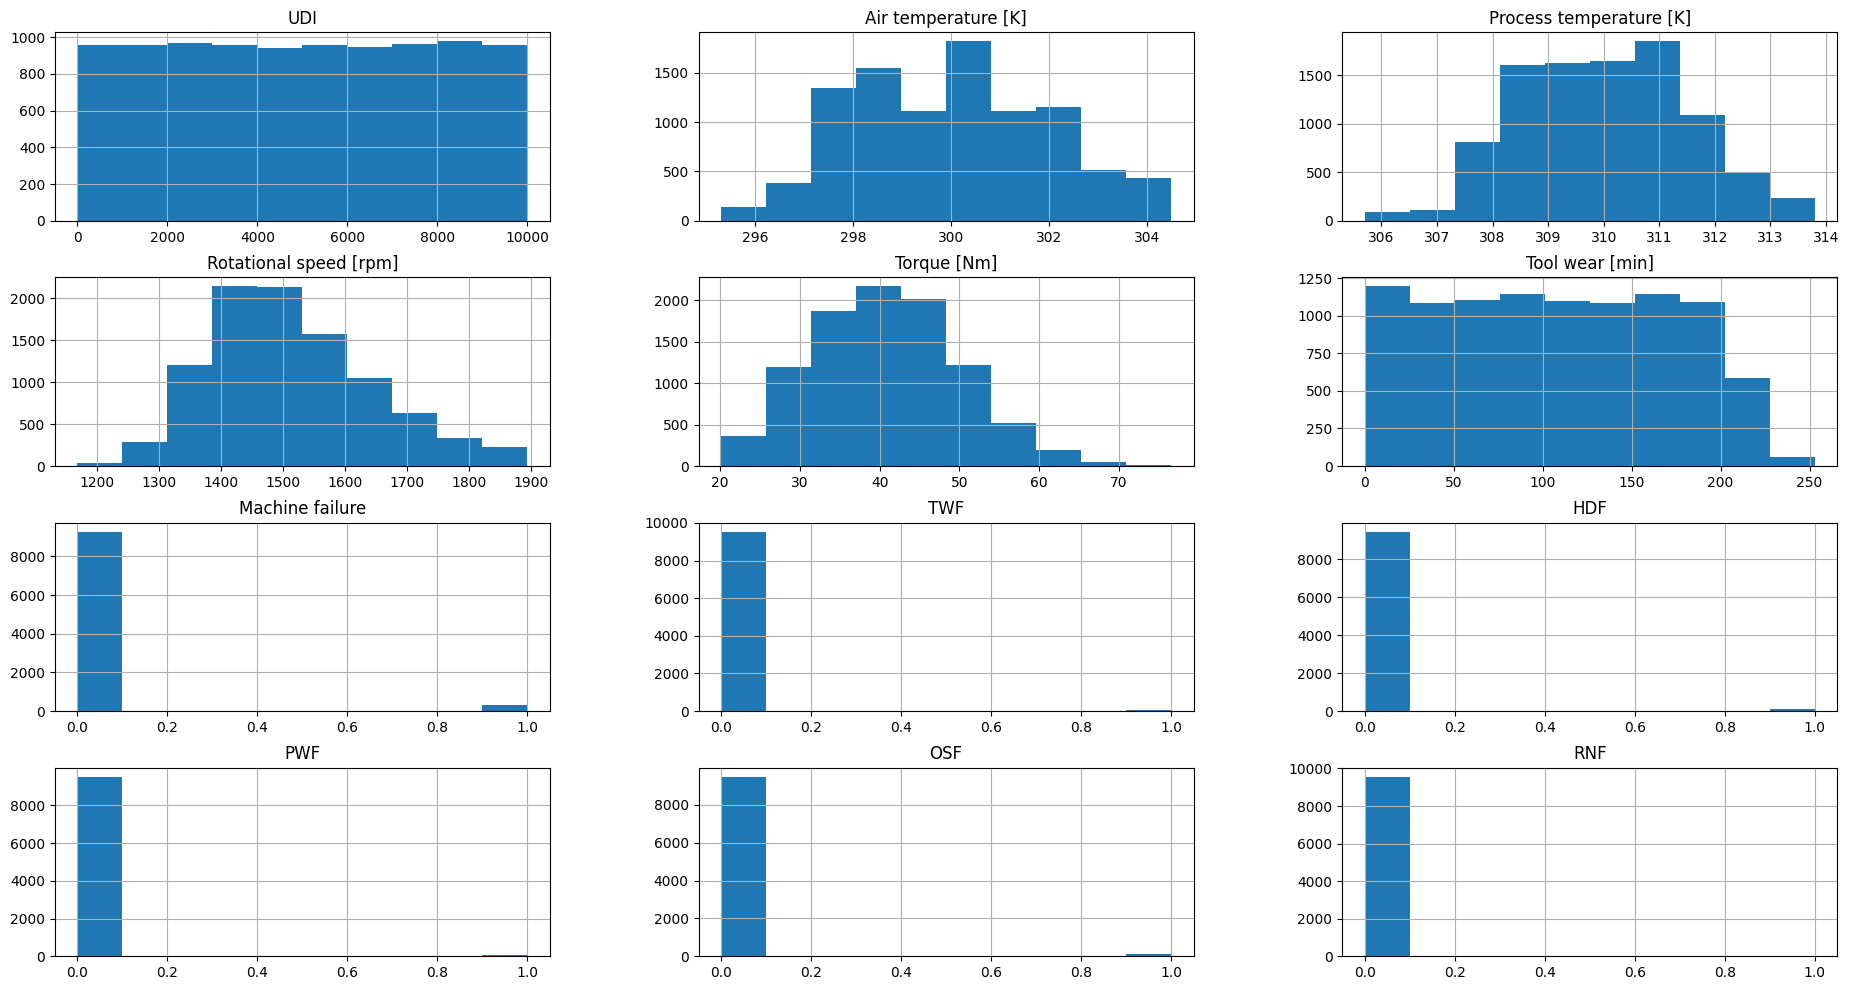

In [141]:
df1_updated.hist(figsize=(23 , 12))

In [142]:

df1_updated_column_rotational_speed = df1_updated['Rotational speed [rpm]'].to_numpy() 

In [143]:
h_values = np.linspace(0.1, 2, 10)  
cv_scores = [cv(h, gaussian_kernel, simple_integrate, df1_updated_column_rotational_speed) for h in h_values]


best_h_rotational_speed = h_values[np.argmin(cv_scores)]
print(f"Best h value for rotational_speed: {best_h_rotational_speed}")

Best h value for rotational_speed: 0.1


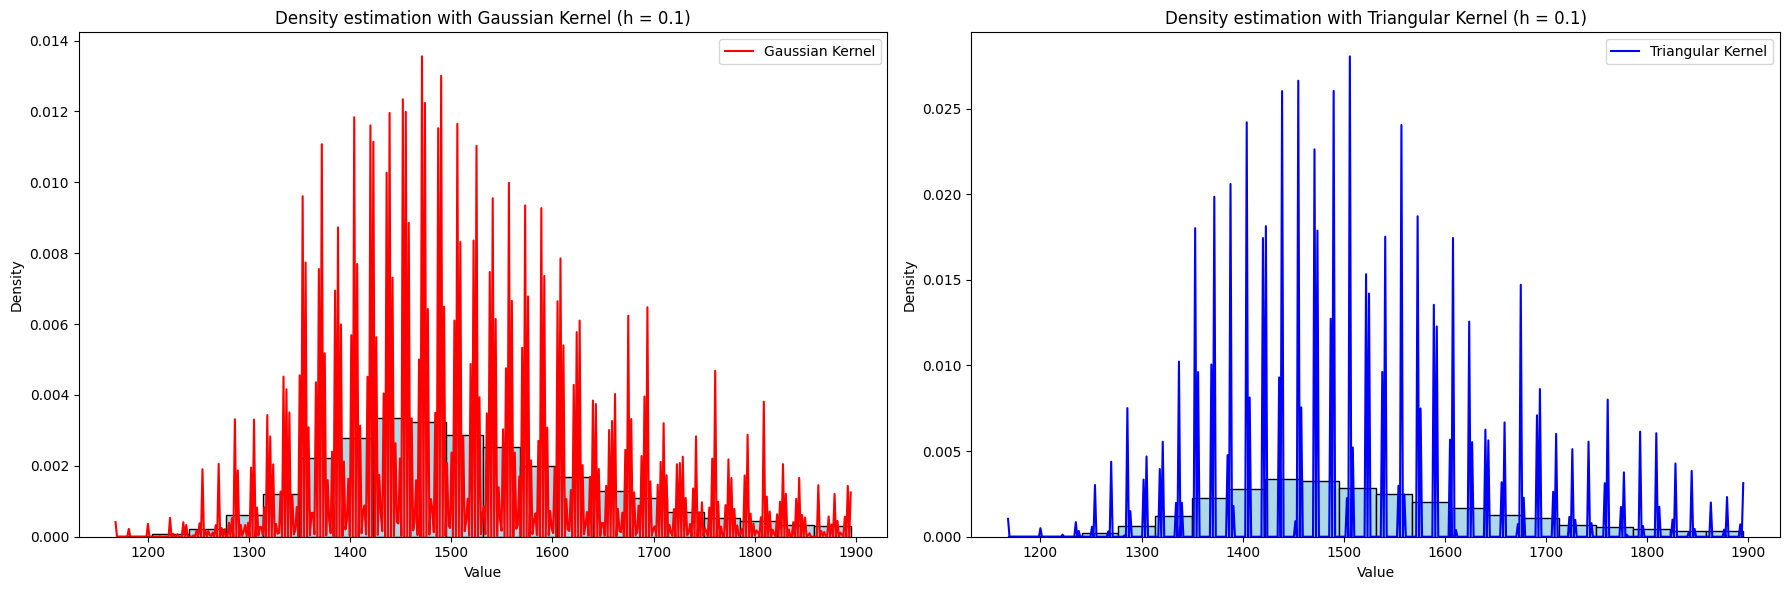

In [144]:
x_df_column_rotational_speed= np.linspace(min(df1_updated_column_rotational_speed) , max(df1_updated_column_rotational_speed) , 500)  # Range of x values for KDE plotting
fig, axs = plt.subplots(1, 2, figsize=(18, 6))


axs[0].hist(df1_updated_column_rotational_speed, bins=20, color='lightblue', edgecolor='black', density=True)
axs[0].plot(x_df_column_rotational_speed, density_estimator(best_h_rotational_speed,x_df_column_rotational_speed, df1_updated_column_rotational_speed, gaussian_kernel), color='red', label="Gaussian Kernel")
axs[0].legend()
axs[0].set_title(f"Density estimation with Gaussian Kernel (h = {best_h_rotational_speed})")
axs[0].set_xlabel("Value")
axs[0].set_ylabel("Density")


axs[1].hist(df1_updated_column_rotational_speed, bins=20, color='lightblue', edgecolor='black', density=True)
axs[1].plot(x_df_column_rotational_speed, density_estimator(best_h_rotational_speed,x_df_column_rotational_speed,df1_updated_column_rotational_speed, triangular_kernel), color='blue', label="Triangular Kernel")
axs[1].legend()
axs[1].set_title(f"Density estimation with Triangular Kernel (h = {best_h_rotational_speed})")
axs[1].set_xlabel("Value")
axs[1].set_ylabel("Density")


plt.tight_layout()
plt.show()

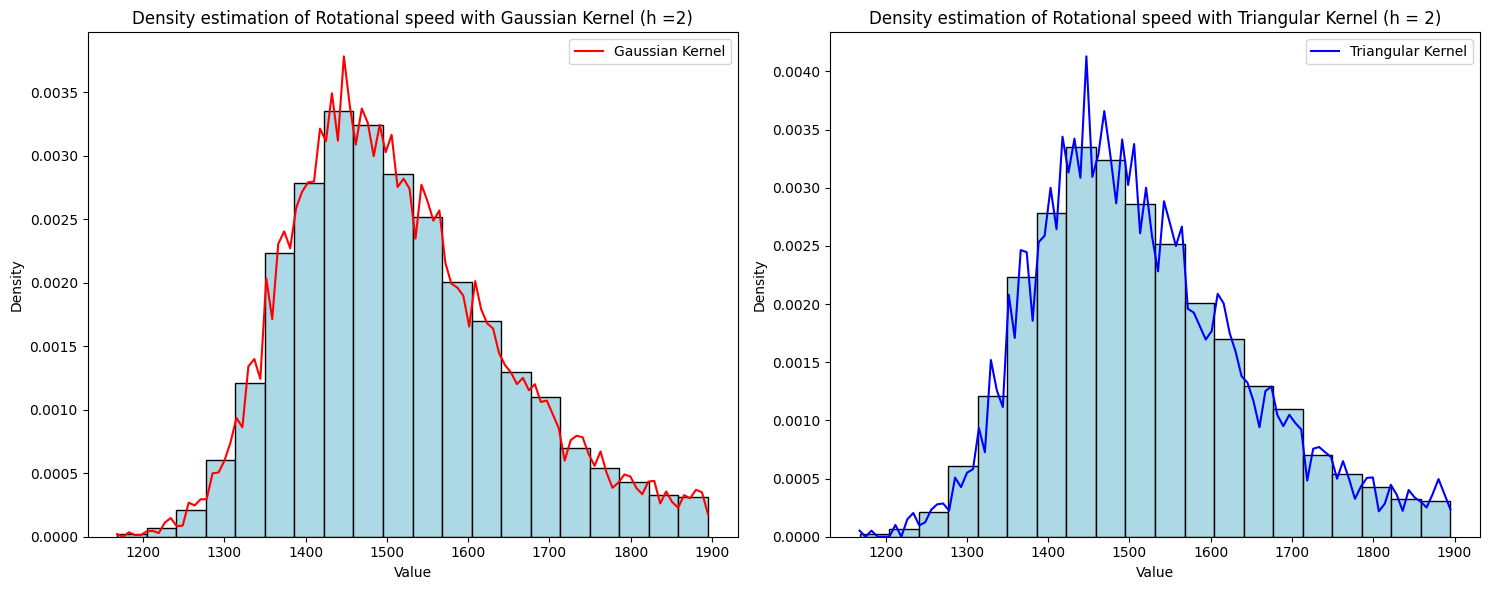

In [145]:
h_r=2
x_df_column_rotational_speed= np.linspace(min(df1_updated_column_rotational_speed) , max(df1_updated_column_rotational_speed) , 100)  # Range of x values for KDE plotting
fig, axs = plt.subplots(1, 2, figsize=(15, 6))


axs[0].hist(df1_updated_column_rotational_speed, bins=20, color='lightblue', edgecolor='black', density=True)
axs[0].plot(x_df_column_rotational_speed, density_estimator(h_r,x_df_column_rotational_speed, df1_updated_column_rotational_speed, gaussian_kernel), color='red', label="Gaussian Kernel")
axs[0].legend()
axs[0].set_title(f"Density estimation of Rotational speed with Gaussian Kernel (h =2)")
axs[0].set_xlabel("Value")
axs[0].set_ylabel("Density")


axs[1].hist(df1_updated_column_rotational_speed, bins=20, color='lightblue', edgecolor='black', density=True)
axs[1].plot(x_df_column_rotational_speed, density_estimator(h_r,x_df_column_rotational_speed,df1_updated_column_rotational_speed, triangular_kernel), color='blue', label="Triangular Kernel")
axs[1].legend()
axs[1].set_title(f"Density estimation of Rotational speed with Triangular Kernel (h = 2)")
axs[1].set_xlabel("Value")
axs[1].set_ylabel("Density")




plt.tight_layout()
#plt.savefig("estimation of Rotational Speed")
plt.show()